# Fixed wing cruise

A cruise held under `coaxial.motion.velocity`, a gust on the load, and the loop's answer.

In [1]:
SIMULATED = True          # False, and PORT, at the bench
PORT = 'COM4'

In [2]:
from coaxial import Coaxial63100

device = Coaxial63100(port=PORT, simulated_device=SIMULATED).open()
print(device)

<Coaxial63100 Simulated SIMULATED>


In [3]:
drive = device.drive
drive.source('model')
drive.model_param(j=2e-5, b=1e-5, load=0.0)
device.gates.arm(bypass_sto=True, ignore_interlock=True)
poles = int(drive.params()['motor_pole_pairs'])
log = []

In [4]:
import math

TWO_PI = 2.0 * math.pi

def prop_load(k):
    def watch(v):
        wm = drive.model()['omega'] / poles
        drive.model_param(load=k * wm * abs(wm))
        log.append((len(log) * v.pause, v.bus.w_ref * 60.0 / TWO_PI, v.rpm_now,
                    v.bus.iq_ref))
    return watch

Cruise at one speed; halfway through the load steps up for a second and back - the gust - while the reference stands still.

In [5]:
import time

K_CRUISE = 2e-8
gust_at = None

def gusty(k):
    inner = prop_load(k)
    def watch(v):
        global gust_at
        now = time.monotonic()
        if gust_at is None:
            gust_at = now
        factor = 2.5 if 2.0 < now - gust_at < 3.0 else 1.0
        inner(v)
        wm = drive.model()['omega'] / poles
        drive.model_param(load=factor * k * wm * abs(wm))
    return watch

with device.motion.velocity(amps=2.0, hz=2.0, load_k=K_CRUISE) as cruise:
    cruise.rpm(2500.0, seconds=1.5, watch=prop_load(K_CRUISE))
    cruise.rpm(2500.0, seconds=5.0, watch=gusty(K_CRUISE))
    print('after the gust: %.0f rpm' % cruise.rpm_now)
    cruise.stop(seconds=1.0)
device.gates.disarm()
drive.model_param(load=0.0)
drive.source('adc')

after the gust: 2507 rpm


True

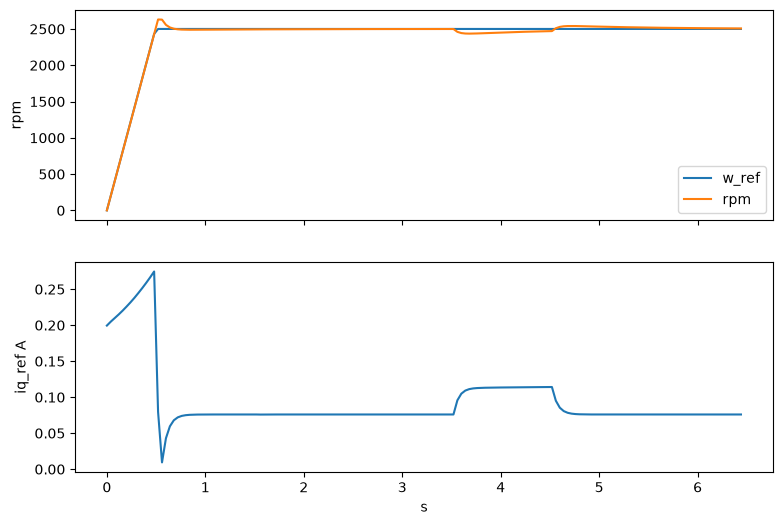

In [6]:
import matplotlib.pyplot as plt

t = [r[0] for r in log]
fig, (a, b) = plt.subplots(2, 1, sharex=True, figsize=(9, 6))
a.plot(t, [r[1] for r in log], label='w_ref'); a.plot(t, [r[2] for r in log], label='rpm')
a.set_ylabel('rpm'); a.legend()
b.plot(t, [r[3] for r in log]); b.set_ylabel('iq_ref A'); b.set_xlabel('s')
plt.show()
device.close()

## Conclusions

In [7]:
settled = [r for r in log if r[0] > 1.0]
cruise = [r for r in settled if r[0] < 3.0]
gust = [r for r in settled if 3.5 < r[0] < 4.5]
after = [r for r in settled if r[0] > 5.0]
for name, rows_ in (('cruise', cruise), ('gust', gust), ('recovered', after)):
    if rows_:
        speed = [r[2] for r in rows_]
        current = [r[3] for r in rows_]
        print('%-10s rpm %6.0f +/- %4.0f    iq_ref %5.2f A'
              % (name, sum(speed) / len(speed), max(speed) - min(speed),
                 sum(current) / len(current)))
print('reference stood still at %.0f rpm throughout' % log[-1][1])

cruise     rpm   2496 +/-    8    iq_ref  0.08 A
gust       rpm   2454 +/-   64    iq_ref  0.11 A
recovered  rpm   2516 +/-   24    iq_ref  0.08 A
reference stood still at 2500 rpm throughout


The reference never moved: the speed error is what the loop sees, and the current is what it answers with. A load that grows with the square of speed cannot be carried by `b`, a linear drag - that reaches the same speed at a torque which is wrong everywhere except the one point it was fitted at, which is why `Motor` carries `k_load` separately.

The feedforward already knows the standing drag `k w |w|`, so the integrator only has to make up the difference the gust adds, and it gives it back when the gust passes. The clamp is `limit`, the amps the verb was opened with.